# DEMI | NOVA FCT

## Fatigue Design of Mechanical Joints and Aerospace Structures

##### José Xavier & Rui Martins

### Problems 10 — Fractography and historical case studies

- [Exercise 10.1](#ex1) — Identifying failure modes from fracture surfaces
- [Exercise 10.2](#ex2) — Fractography of three specimens
- [Exercise 10.3](#ex3) — de Havilland Comet case study
- [Exercise 10.4](#ex4) — Aloha Airlines Flight 243 case study
- [Exercise 10.5](#ex5) — Soderberg with $K_t$: safe design stress


In [1]:
import numpy as np
import matplotlib.pyplot as plt

FS = 14

# Reset to default style so any IDE dark-theme overrides do not bleed in.
plt.style.use('default')

plt.rcParams.update({
    'figure.figsize':   (10, 4.2), 'figure.dpi': 110,
    'font.family':      'serif',  'font.size': FS,
    'axes.grid':        True,     'grid.alpha': 0.30,
    'lines.linewidth':  2,
    # --- Backgrounds (white) ---
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'savefig.facecolor':'white',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    # --- Force all text BLACK so the IDE dark theme does not hide it ---
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'axes.edgecolor':   'black',
    'axes.titlecolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'legend.labelcolor':'black',
})
COLORS = dict(curve='#1f4e79', point='#c0392b', accent='#8e44ad',
              guide='0.55', warn='#e67e22', cool='#16a085')


<a id='ex1'></a>
---

## 10.1 — Identifying failure modes from fracture surfaces

**(a)** Describe the macroscopic features of a fatigue fracture surface. How do you distinguish fatigue from: (i) static overload, (ii) stress corrosion cracking?

**(b)** On a fatigue fracture surface, identify and explain: beach marks (arrest lines), ratchet marks, striations, and the final fast-fracture zone. What information does each feature convey about the loading history?

**(c)** A failed component shows a smooth, flat fracture surface with concentric arc-shaped marks converging to a single point at the surface. What is the most likely failure mode? Where did the crack initiate?

### Solution

**(a) Macroscopic features of a fatigue fracture.**

* **Flat, smooth zone** (~70–90 % of the section) traversing slowly under
  cyclic load.
* **Beach marks (arrest lines)** — concentric arcs centred on the initiation
  point, recording changes in load amplitude or environment.
* **Ratchet marks** — small radial steps perpendicular to the crack front,
  marking multiple coalescing initiation sites.
* **Final fast-fracture zone** — rough, fibrous (ductile) or crystalline
  (brittle), where $K_{\max}$ reaches $K_{IC}$.

| Failure mode | Distinguishing features |
|---|---|
| Fatigue | flat smooth zone + beach marks + small fast zone |
| Static overload | overall rough, dimpled (ductile) or cleavage (brittle); no beach marks; necking in ductile case |
| Stress corrosion | flat zone with branched secondary cracks, often intergranular; pitting near initiation |

**(b) Detailed features.**

* **Beach marks** — set the *macroscopic* load history (each arc = a change
  in load amplitude or a pause). Visible to the naked eye or low-mag optical.
* **Ratchet marks** — count of initiation sites. Many ratchet marks → high
  stress amplitude relative to fatigue limit, or stress raiser distributed
  along the perimeter.
* **Striations** — *microscopic* features visible only on SEM. Each striation
  corresponds (approximately) to **one load cycle**. Measuring striation
  spacing gives $\mathrm{d}a/\mathrm{d}N$ directly.
* **Final fast-fracture zone** — its area + applied force gives the residual
  strength at the moment of failure.

**(c) Smooth flat surface with concentric arcs to one surface point.**

Single-origin **rotating-bending fatigue**. The crack initiated at the
surface (where the cyclic bending stress is maximum), and the beach marks
are concentric arcs. If radial ratchet marks were absent, only one initiation
site was active.


<a id='ex2'></a>
---

## 10.2 — Fractography of three specimens

Three specimens were tested and their fracture surfaces examined. For each, determine: (a) the fracture type (ductile, brittle, fatigue), (b) the loading type (tension, bending, torsion), and (c) the probable failure origin.

**(a)** A cylindrical shaft showing a smooth, flat fracture surface covering approximately 80% of the cross-section, with a small, rough region (shear lip) at the edge. Beach marks are visible, radiating from a surface scratch.

**(b)** A rectangular plate showing a cup-and-cone fracture with extensive necking. The fracture surface is rough and dimpled.

**(c)** A cylindrical component with a fracture surface at $45^\circ$ to the axis, showing a smooth, helical pattern with no beach marks.

### Solution

**Specimen 1.** Cylindrical shaft; flat zone (~80 %) + small shear lip;
beach marks radiating from a **surface scratch**.

* Fracture type: **fatigue**.
* Loading: **bending** (or rotating bending) — flat zone propagates from a
  surface point, the shear lip is a small final-overload region.
* Origin: the **scratch** acts as a stress concentrator; crack initiates there.

**Specimen 2.** Rectangular plate, cup-and-cone, extensive necking, rough
**dimpled** surface.

* Fracture type: **ductile static overload**.
* Loading: **uniaxial tension**.
* Origin: triaxial stress concentration at the centre of the neck —
  microvoid nucleation, coalescence, then shear lips at 45°.

**Specimen 3.** Cylindrical, fracture at 45° to the axis, **smooth helical**
pattern, **no beach marks**.

* Fracture type: **brittle static torsion** (single-cycle failure).
* Loading: **pure torsion** — the maximum principal tensile stress is on a
  helix at 45° to the axis. A brittle material splits along that helix.
* Origin: surface, where the shear stress is maximum.

The absence of beach marks is the deciding clue: a *fatigue* torsion failure
would show a step-like flat zone with stair-cased ratchet marks, not a
smooth helix.


<a id='ex3'></a>
---

## 10.3 — de Havilland Comet case study

**(a)** Describe the sequence of events that led to the Comet accidents (1954). Where did the fatigue crack initiate? What was the role of the window geometry?

**(b)** Compute the stress concentration factor at the corner of a square window with a small fillet radius. Why did the original design use near-square windows?

**(c)** What design changes were implemented after the investigation? How do these relate to the fatigue concepts studied in this course (stress concentration, SIF, residual strength)?

### Solution

**(a) Sequence of events.**

* The Comet 1 was the first pressurised commercial jet (8 psi cabin pressure).
* In 1954 two aircraft (Yoke Peter, Yoke Yoke) broke up in flight near Elba
  and Stromboli respectively, after roughly 1290 and 900 pressurisation cycles.
* The RAE investigation (Cohen, Hill) located the **initiation site at the
  corner of a square ADF (radio) window** in the cabin skin. The crack ran
  longitudinally, then circumferentially, until the entire cabin unzipped.
* Pressurisation cycles produced a hoop stress that, combined with the very
  high stress concentration at the window corner, exceeded the fatigue limit
  of the aluminium skin.

**(b) Stress concentration at a square corner with a small fillet $r$.**

For a square aperture in a thin plate under remote tension, the Inglis-type
estimate (Eq. 5.1) with the fillet radius as effective root radius gives
$K_t = 1 + 2\sqrt{a/\rho}$. The half-aperture $a$ for the Comet window was
$\sim 40$ cm, $\rho \sim 2$ mm at the corner fillet → $K_t \sim 1 + 2\sqrt{200}
\approx 30$ (an order of magnitude higher than the design assumption).

The design choice of *near-square* windows came from manufacturing convenience:
square panes are easier to make, ship, install and replace; the importance of
curving the corners was not appreciated at the time.

**(c) Design changes after the investigation.**

* **Rounded windows.** Modern airliners use elliptical / oval windows with
  *large* corner radii — $K_t$ at the corner drops from $\sim 30$ to $\sim 3$.
* **Heavier reinforcing doublers** around every cabin penetration.
* **Damage-tolerance philosophy** — assume the largest credible undetected
  crack and design so it cannot grow to critical between inspections (FAR 25
  / EASA CS-25).
* **Full-scale fatigue testing** of pressurised airframes before
  certification became mandatory.
* **NDI** of fatigue-critical regions on a fixed schedule.

These map directly onto our course concepts: (i) reducing $K_t$ (Problem 2);
(ii) admitting the existence of cracks and quantifying them by $K$ (Problem 3);
(iii) limiting service stress so $a_c$ exceeds the inspection-detectable size
(Problem 3.4); and (iv) treating the residual strength diagram as the
design envelope (Problem 3.10).


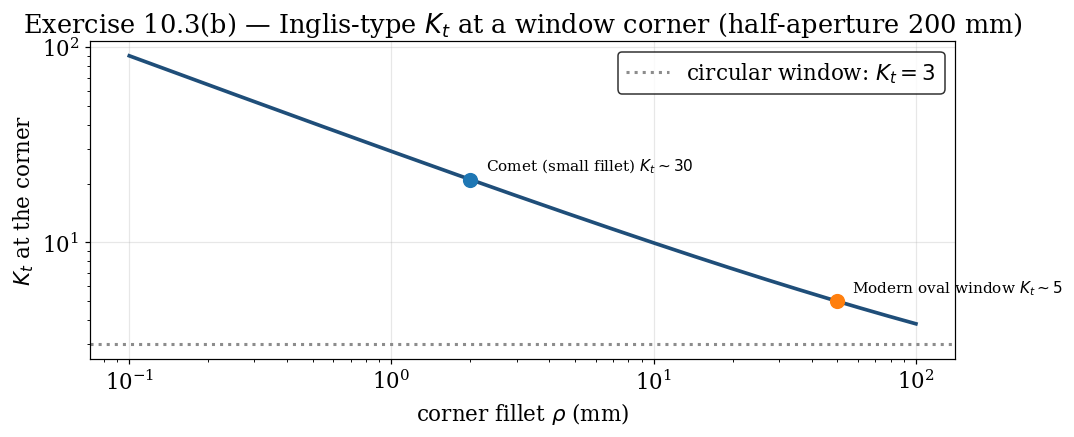

In [2]:
# Illustrate K_t at a square corner using Inglis with effective root radius
a_aperture = 200.0   # mm  (half-aperture of the Comet window, illustrative)
rho_arr = np.logspace(-1, 2, 200)   # mm
Kt_arr = 1 + 2*np.sqrt(a_aperture/rho_arr)

fig, ax = plt.subplots()
ax.loglog(rho_arr, Kt_arr, color=COLORS['curve'], lw=2.4)
ax.axhline(3, color=COLORS['guide'], ls=':', label='circular window: $K_t=3$')
# Annotate two design choices
for rho, lbl in [(2, 'Comet (small fillet) $K_t\sim 30$'),
                 (50, 'Modern oval window $K_t\sim 5$')]:
    Kt = 1 + 2*np.sqrt(a_aperture/rho)
    ax.scatter([rho], [Kt], s=80, zorder=5)
    ax.annotate(lbl, (rho, Kt), xytext=(10, 6), textcoords='offset points', fontsize=10)
ax.set_xlabel(r'corner fillet $\rho$ (mm)')
ax.set_ylabel(r'$K_t$ at the corner')
ax.set_title(r'Exercise 10.3(b) — Inglis-type $K_t$ at a window corner (half-aperture 200 mm)')
ax.legend(); plt.tight_layout(); plt.show()


<a id='ex4'></a>
---

## 10.4 — Aloha Airlines Flight 243 case study

**(a)** Describe the concept of *multi-site damage* (MSD) and explain how it contributed to the Aloha Airlines fuselage failure (1988).

**(b)** How does MSD differ from a single dominant crack in terms of residual strength and detectability?

**(c)** What are the implications of MSD for damage-tolerance-based inspection programmes?

### Solution

**(a) Multi-site damage (MSD).**

In a structure with many similar stress raisers loaded by the same cyclic
load (a rivet row, a row of bolt holes), each hole can develop a small
fatigue crack independently. **MSD** denotes the simultaneous presence of
*many* small cracks at neighbouring holes. The phenomenon was central to
Aloha 243: the 19-year-old B-737 had thousands of pressurisation cycles, and
the rivet holes of the upper fuselage lap-joint had developed cracks at
nearly every hole. When one ligament between two cracks broke, the others
unzipped immediately, and an 18-foot section of the upper fuselage tore
away in flight.

**(b) MSD vs. a single dominant crack.**

* **Residual strength.** A single long crack of total length $L$ has lower
  residual strength than several short cracks of the same total length —
  intuition says MSD is "safer". *Wrong.* When the cracks coalesce, the
  combined ligament fails much earlier than the largest single crack would
  predict. The transition from many-short-cracks to one-long-crack is
  catastrophic and *not* captured by single-crack LEFM.
* **Detectability.** Individual MSD cracks are typically below the $a_{90/95}$
  of standard eddy-current NDI; the **population** of small cracks is below
  detection even when the **combined risk** is already high.

**(c) Implications for damage-tolerant inspection.**

* Inspect for the **combined crack length** across multiple holes, not just
  the largest single crack.
* Specifically check for **lap-joint disbond** — MSD is most dangerous when
  hidden by an external rivet head.
* Replace **fail-safe** philosophy (multiple redundant load paths) with
  **damage-tolerance + MSD aware** assumptions for ageing aircraft.
* Triggered the Aging Aircraft Programme (AAP) and the **Aging Transport
  Systems Rulemaking Advisory Committee** (ATSRAC) in the late 1980s –1990s.


<a id='ex5'></a>
---

## 10.5 — Soderberg with $K_t$: safe design stress

A cylindrical component with a circumferential notch ($K_t = 2.5$) is made of a steel with $\sigma_e = 600$ MPa, $\sigma_u = 900$ MPa and $\sigma_{f0} = 400$ MPa (for $R = -1$, unnotched). The notch sensitivity factor is $q = 0.8$.

**(a)** Compute the fatigue strength reduction factor $K_f$.

**(b)** Construct the Soderberg diagram for the notched component (replace $\sigma_{f0}$ with $\sigma_{f0}/K_f$).

**(c)** Determine the maximum allowable stress amplitude for a loading with $R = 0$ (pulsating).

### Solution

#### (a) Fatigue strength reduction factor $K_f$

\begin{equation*}
K_f = 1 + q(K_t-1) = 1 + 0.8\cdot 1.5 = 2.20.
\tag{10.5.1}\end{equation*}


In [3]:
K_t, q = 2.5, 0.8
sigma_e, sigma_u, sigma_f0 = 600.0, 900.0, 400.0
K_f = 1 + q*(K_t - 1)
sigma_f0_notch = sigma_f0/K_f
print(f'(a) K_f = 1 + q(K_t - 1) = 1 + {q}·{K_t-1:.2f} = {K_f:.3f}')
print(f'    Fatigue limit of the notched component (R=-1):  σ_f0/K_f = {sigma_f0_notch:.2f} MPa')


(a) K_f = 1 + q(K_t - 1) = 1 + 0.8·1.50 = 2.200
    Fatigue limit of the notched component (R=-1):  σ_f0/K_f = 181.82 MPa


#### (b) Soderberg diagram for the notched component

Replace $\sigma_{f0}$ with $\sigma_{f0}/K_f$ in the Soderberg formula:

\begin{equation*}
\dfrac{\sigma_a}{\sigma_{f0}/K_f} + \dfrac{\sigma_m}{\sigma_e} = 1.
\tag{10.5.2}\end{equation*}


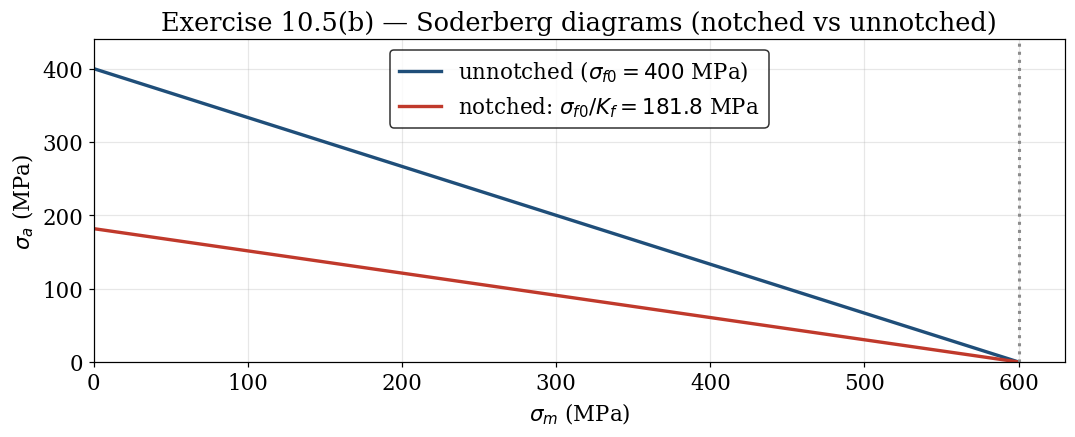

In [4]:
sm = np.linspace(0, sigma_e, 400)
sa_unnotched = sigma_f0*(1 - sm/sigma_e)
sa_notched   = sigma_f0_notch*(1 - sm/sigma_e)

fig, ax = plt.subplots()
ax.plot(sm, sa_unnotched, color=COLORS['curve'], lw=2.2, label='unnotched ($\\sigma_{f0}=400$ MPa)')
ax.plot(sm, sa_notched,   color=COLORS['point'], lw=2.2,
        label=fr'notched: $\sigma_{{f0}}/K_f = {sigma_f0_notch:.1f}$ MPa')
ax.axvline(sigma_e, color=COLORS['guide'], ls=':')
ax.set_xlabel(r'$\sigma_m$ (MPa)'); ax.set_ylabel(r'$\sigma_a$ (MPa)')
ax.set_title('Exercise 10.5(b) — Soderberg diagrams (notched vs unnotched)')
ax.set_xlim(0, sigma_e*1.05); ax.set_ylim(0, sigma_f0*1.1)
ax.legend(); plt.tight_layout(); plt.show()


#### (c) Maximum $\sigma_a$ for $R=0$ (pulsating)

For $R=0$, $\sigma_m = \sigma_a$. Substitute in (10.5.2):

\begin{equation*}
\sigma_a = \dfrac{1}{1/(\sigma_{f0}/K_f) + 1/\sigma_e}.
\tag{10.5.3}\end{equation*}


In [5]:
sa_pulsating = 1/(1/sigma_f0_notch + 1/sigma_e)
print(f'(c) For R=0 (σ_m = σ_a):')
print(f'    σ_a^max = 1/(1/(σ_f0/K_f) + 1/σ_e) = {sa_pulsating:.2f} MPa')
print(f'    σ_max  = 2·σ_a^max ≈ {2*sa_pulsating:.2f} MPa')


(c) For R=0 (σ_m = σ_a):
    σ_a^max = 1/(1/(σ_f0/K_f) + 1/σ_e) = 139.53 MPa
    σ_max  = 2·σ_a^max ≈ 279.07 MPa


### Solution summary — Exercise 10.5

| Quantity | Symbol | Value |
|---|---|---|
| Stress-concentration factor | $K_t$ | 2.500 |
| Notch-sensitivity factor | $q$ | 0.800 |
| Fatigue-strength reduction factor | $K_f = 1 + q(K_t-1)$ | **2.200** |
| Fatigue limit of notched component ($R = -1$) | $\sigma_{f0}/K_f$ | **181.82 MPa** |
| Max. stress amplitude ($R = 0$, Soderberg) | $\sigma_a^{\max}$ | **139.53 MPa** |
| Max. peak stress ($R = 0$) | $\sigma_{\max} = 2\,\sigma_a^{\max}$ | **279.07 MPa** |

---

### Final remarks

* Fractographic analysis — although qualitative — is the **first** diagnostic
  step in any failure investigation. The macroscopic features uniquely
  identify the failure mode in 80 % of cases.
* The two case studies (Comet 1954, Aloha 1988) cover a 34-year span and
  illustrate **the maturation of damage tolerance** from "no fatigue cracks
  allowed" (safe-life) to "we know cracks exist and we manage them"
  (damage-tolerance) and finally to "we know there are *many* cracks and we
  must plan accordingly" (MSD-aware design).
* The Soderberg-with-$K_t$ construction (Ex 10.5) is the practical tool to
  set safe design stresses for notched components subjected to non-zero mean
  stress — the standard pre-Eurocode 3 sizing rule for shafts and bolts.


---

Copyright (c) DEMI - NOVA FCT

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

Parts of this notebook were prepared with AI assistance (<a href="https://www.anthropic.com/claude-code" target="_blank">Claude Code</a>, Anthropic), reviewed and verified by the author.